# Imports

In [3]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import cv2 
from scipy.signal import convolve2d 
from scipy.fft import ifft2 

# Questão 08

In [4]:
pwd

'/home/manuel/projects/repos/mestrado/pdi/notebooks'

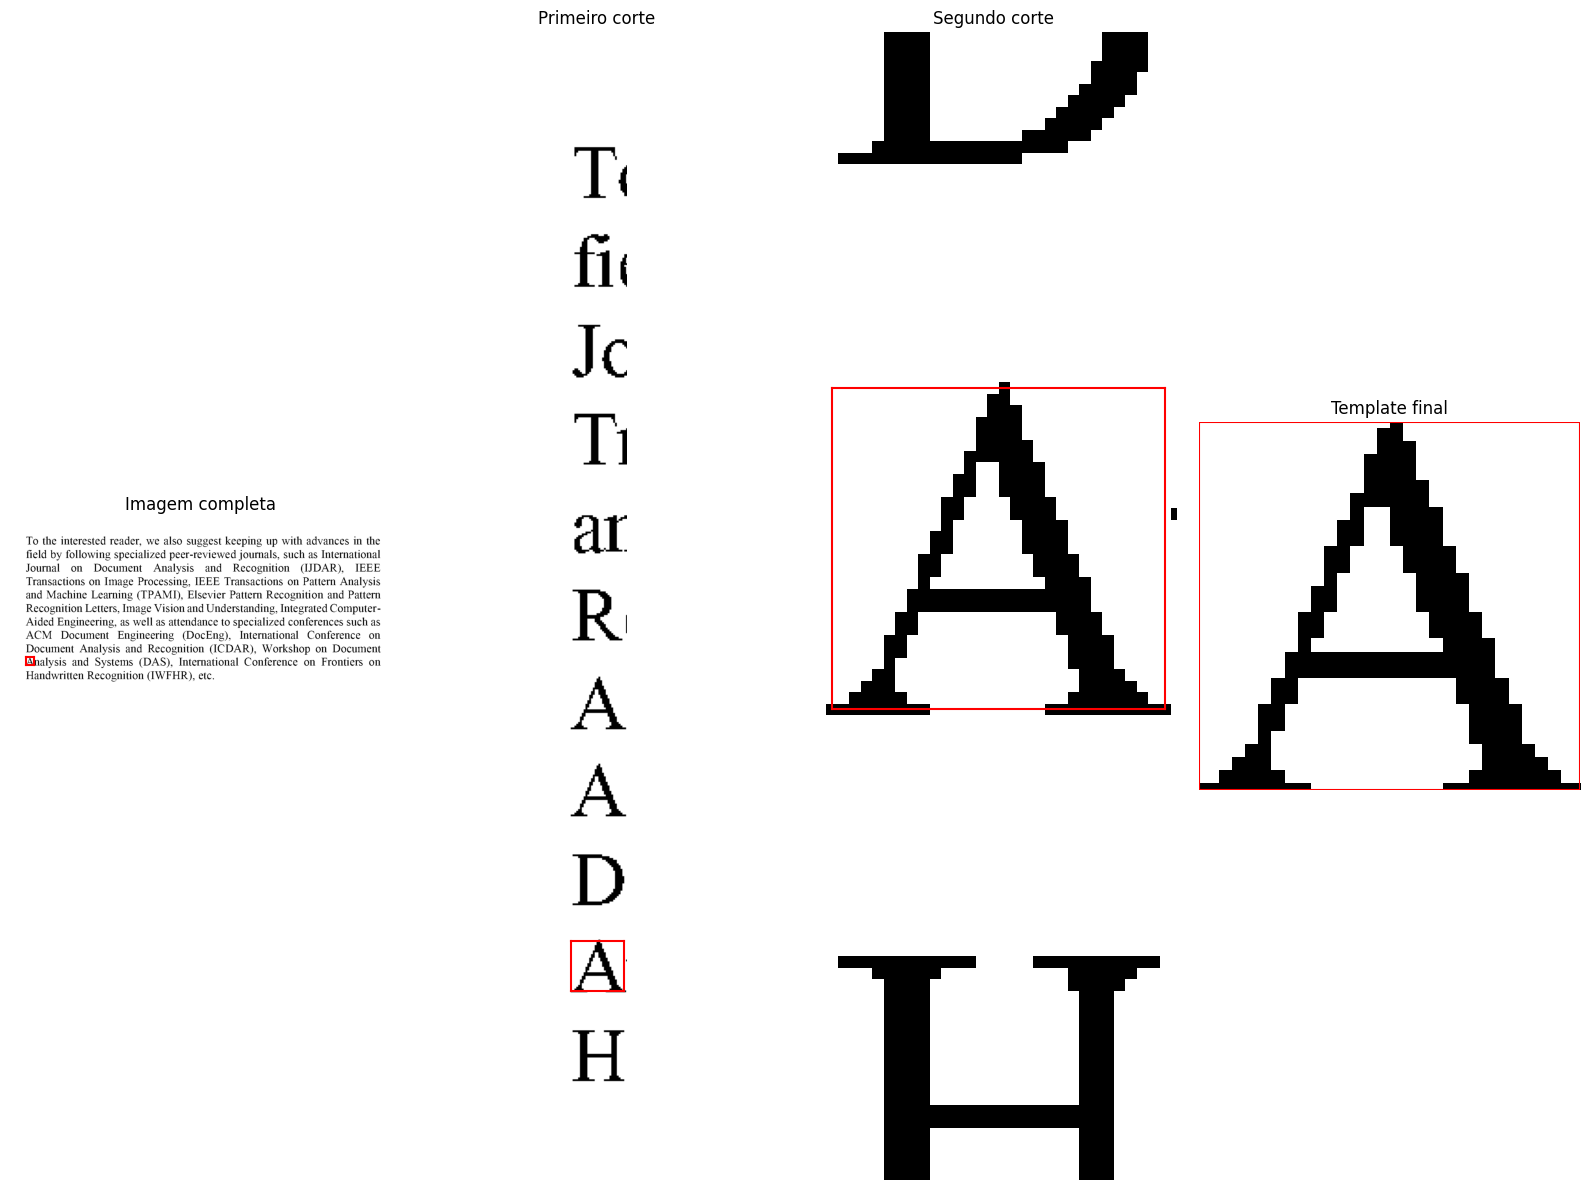

In [10]:
image_path_1 = "../assets/atv02_lista02-assets/Book_1.png" 
image_path_2 = "../assets/atv02_lista02-assets/Book_2.png" 
image_book1 = cv2.imread(image_path_1, cv2.IMREAD_GRAYSCALE) 
image_book2 = cv2.imread(image_path_2, cv2.IMREAD_GRAYSCALE)

 # Configurando cortes das imagens para procura 
cortes = { 
"Imagem completa": ((0, image_book1.shape[0]), (0, 
image_book1.shape[1])), 
"Primeiro corte": ((0, image_book1.shape[0]), (55, 87)), 
"Segundo corte": ((470, 570), (55, 87)), 
"Template final": ((501, 529), (57, 86)) 
} 


fig, ax = plt.subplots(1, len(cortes), figsize=(16, 12)) 
if not isinstance(ax, np.ndarray): 
    ax = np.array([ax]) 
for idx, (title, sliced) in enumerate(cortes.items()): 
    ax[idx].imshow(image_book1, cmap='gray') 
    ax[idx].axis('off') 
    if idx > 0:
        ax[idx].set_ylim(sliced[0][1], sliced[0][0]) 
        ax[idx].set_xlim(sliced[1][0], sliced[1][1]) 
#if idx == 0: 
    x_init, x_end = cortes["Template final"][1] 
    y_init, y_end = cortes["Template final"][0] 
    ax[idx].plot( 
        [x_init] * np.ones(len(np.arange(y_init, y_end +1 ))), 
        np.arange(y_init, y_end + 1), 
        color='red', 
        label='Média da linha' 
    ) 
    ax[idx].plot( 
        [x_end] * np.ones(len(np.arange(y_init, y_end+ 1))), 
        np.arange(y_init, y_end + 1), 
        color='red', 
        label='Média da linha' 
    ) 
    ax[idx].plot( 
        np.arange(x_init, x_end+ 1), 
        [y_init] * len(np.arange(x_init, x_end+ 1)), 
        color='red', 
        label='Média da linha' 
    ) 
    ax[idx].plot( 
        np.arange(x_init, x_end+ 1), 
        [y_end] * len(np.arange(x_init, x_end+ 1)), 
        color='red', 
        label='Média da linha' 
    ) 
    ax[idx].set_title(title) 
fig.tight_layout() 
# fig.savefig("assets/atv02-q08-s1-00.png", dpi=400, bbox_inches='tight') 
plt.show() 

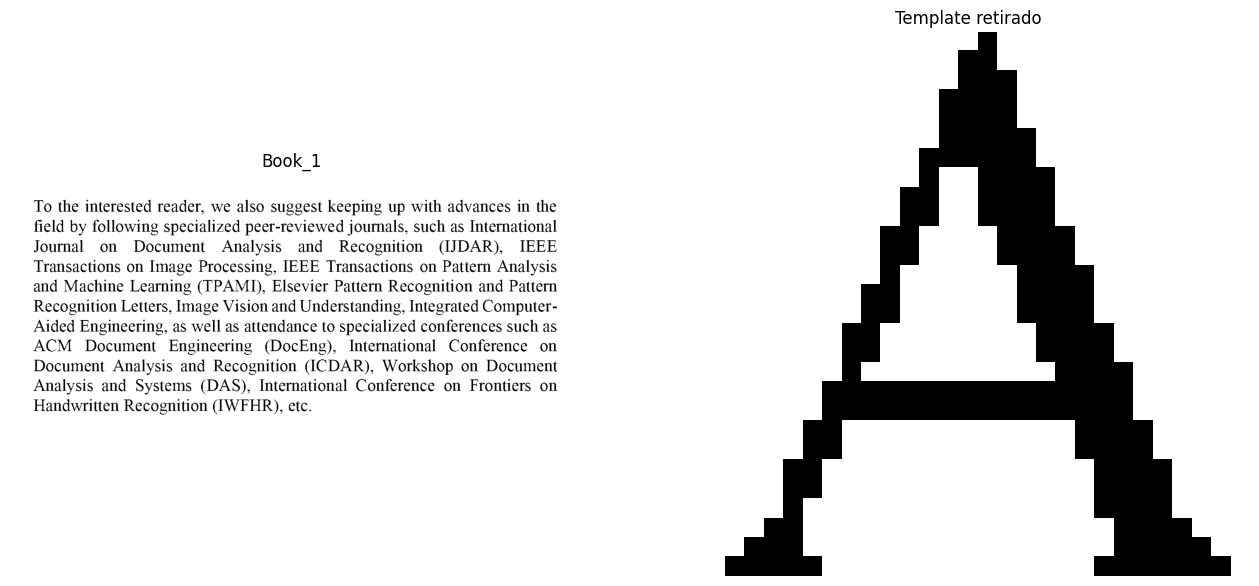

In [11]:
template = image_book1[ 
    slice(*cortes["Template final"][0]), 
    slice(*cortes["Template final"][1]) 
] 
fig, ax = plt.subplots(1, 2, figsize=(16, 10)) 
ax[0].imshow( 
    image_book1, cmap="gray" 
) 
ax[0].set_title("Book_1") 
ax[1].imshow( 
    template, 
    cmap='gray' 
) 
ax[1].set_title("Template retirado") 
for _ax in ax: 
    _ax.axis("off") 

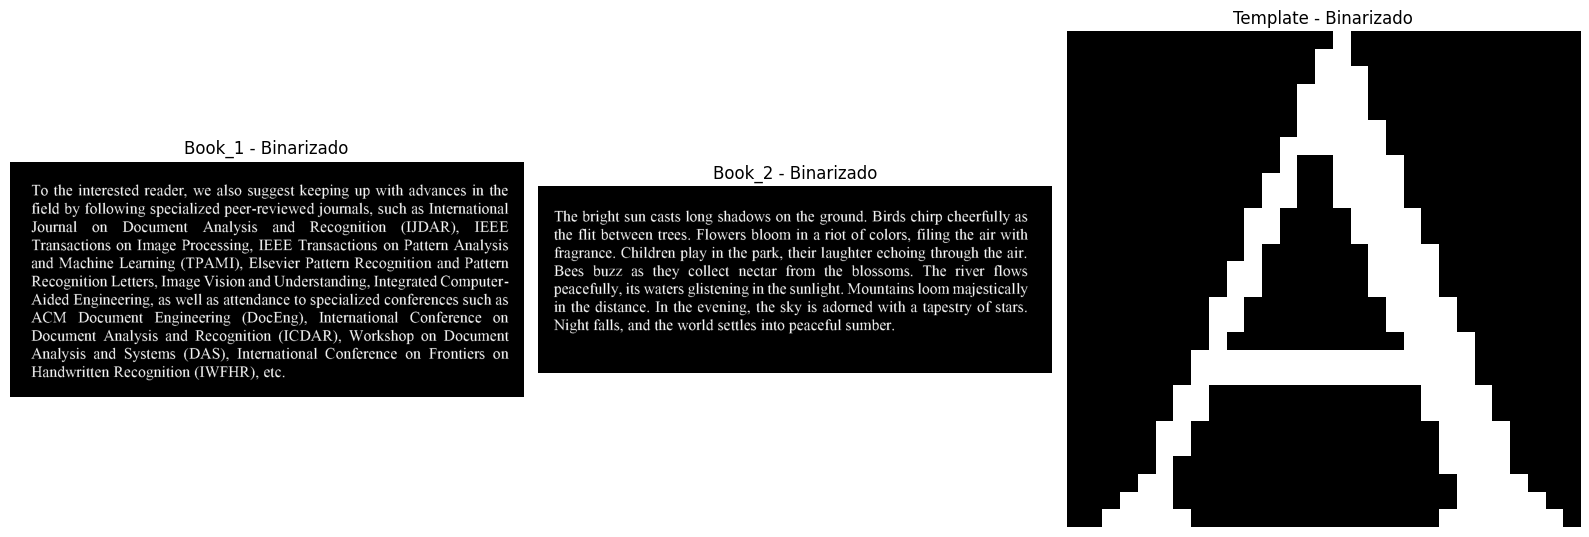

In [13]:
 # binarização 
_, template_mask = cv2.threshold(template, 127, 255, cv2.THRESH_BINARY_INV) 
_, image_mask_1 = cv2.threshold(image_book1, 127, 255, 
cv2.THRESH_BINARY_INV) 
_, image_mask_2 = cv2.threshold(image_book2, 127, 255, 
cv2.THRESH_BINARY_INV) 
# dicionario a ser usado posteriormente 
imgs_mask = { 
"Book_1 - Binarizado": image_mask_1, 
"Book_2 - Binarizado": image_mask_2, 
"Template - Binarizado": template_mask 
} 
lista_books = list(imgs_mask.keys())[:(-1)] # seleção apenas dos books (exceto o template) 
# Plot 
fig, ax = plt.subplots(1, len(imgs_mask.keys()), figsize=(16, 10)) 
for (title, content), _ax in zip(imgs_mask.items(), ax.flatten()): 
    _ax.imshow( 
        content, 
        cmap="gray" 
    ) 
    _ax.set_title(title) 
    _ax.axis("off") 
fig.tight_layout() 
# fig.savefig("assets/atv02-q08-s1-02.png", dpi=400, bbox_inches='tight') 
plt.show() 

In [14]:
# aplicar erosão morfológica usando o template como struct 
eroded_results = {} 
for name in lista_books: 
    eroded_results[name] = { 
"eroded": cv2.erode( 
            imgs_mask[name], 
            template_mask, 
            iterations=1 
        ) / 
255  # Normalizando para [0, 1] 
    } 
    eroded_results[name]["contains_A"] = bool(eroded_results[name]
 ["eroded"].sum() > 0) 
    eroded_results[name]["total-of_A"] = int(eroded_results[name]
 ["eroded"].sum()) 

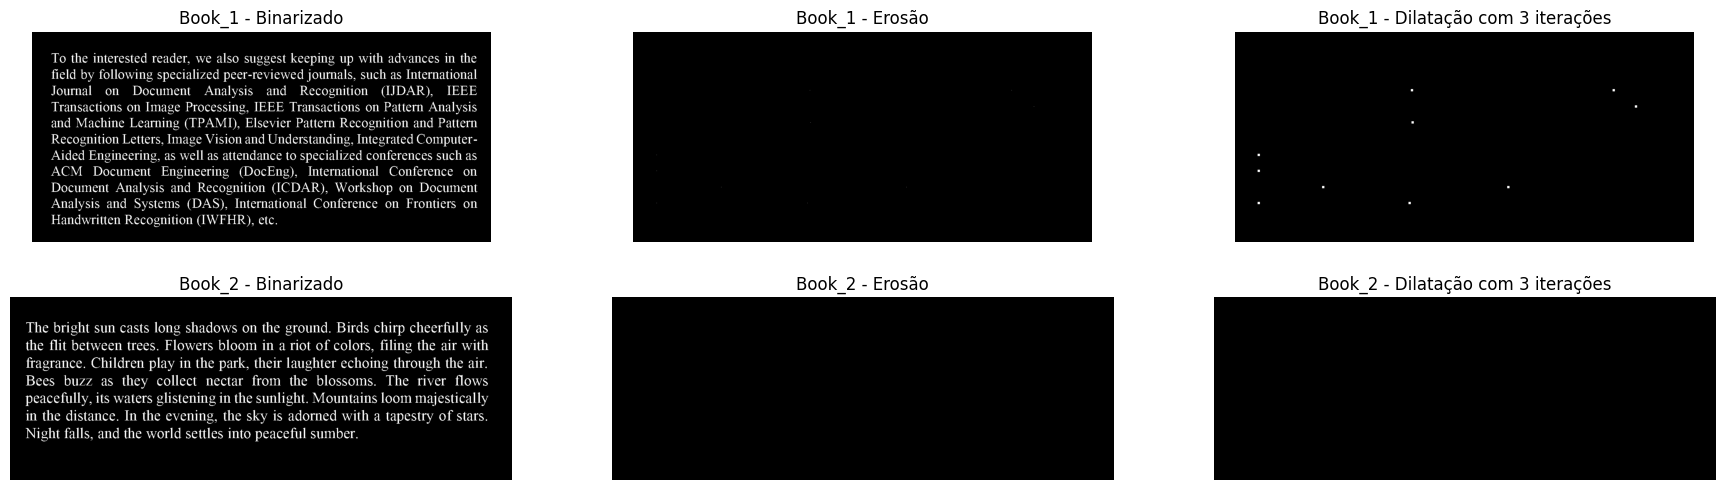

In [18]:

dilated = {} 
k_iter = 3
for name in lista_books: 
    dilated[name] = cv2.dilate( 
        eroded_results[name]["eroded"].astype(np.uint8), 
        kernel=np.ones((3, 3), np.uint8), iterations=k_iter 
    ) 
fig, ax = plt.subplots(2, 3, figsize=(22, 6)) 
for idx, lista in enumerate(lista_books): 
    ax[idx, 0].imshow( 
        imgs_mask[lista], 
        cmap="gray"
    ) 
    ax[idx, 1].imshow( 
        eroded_results[lista]["eroded"], 
        cmap="gray" 
    ) 
    ax[idx, 2].imshow( 
        dilated[lista], 
        cmap="gray" 
    ) 
    for _ax in ax[idx, :]: 
        _ax.axis("off") 
    ax[idx, 0].set_title(lista) 
    ax[idx, 1].set_title(lista.split(" - ")[0] + " - Erosão") 
    ax[idx, 2].set_title(lista.split(" - ")[0] + f" - Dilatação com {k_iter} iterações") 
# fig.savefig("assets/atv02-q08-s1-03.png", dpi=400, bbox_inches='tight')

In [19]:
for key, content in eroded_results.items(): 
    print("-" * 30) 
    print(key.split(" - ")[0]) 
    print(f"Possuí a letra A: {content['contains_A']}") 
    if content["contains_A"]: 
        print(f"Total de letra A: {content['total-of_A']}") 
print("-"*30) 

------------------------------
Book_1
Possuí a letra A: True
Total de letra A: 10
------------------------------
Book_2
Possuí a letra A: False
------------------------------


# Questão 09

In [21]:
img_names = ["cameraman.png", "cameraman_pattern.png"] 
imgs = { 
    i.split(".")[0]: cv2.imread(f"../assets/atv02_lista02-assets/{i}", cv2.IMREAD_GRAYSCALE) for i in img_names 
}

In [24]:
# Função para calcular transformada e obter magnitude
def apply_fourier_transform(image): 
    f_transform = np.fft.fft2(image) 
    f_shift = np.fft.fftshift(f_transform) 
    magnitude = np.log(np.abs(f_shift) + 1) 
    return magnitude, f_shift

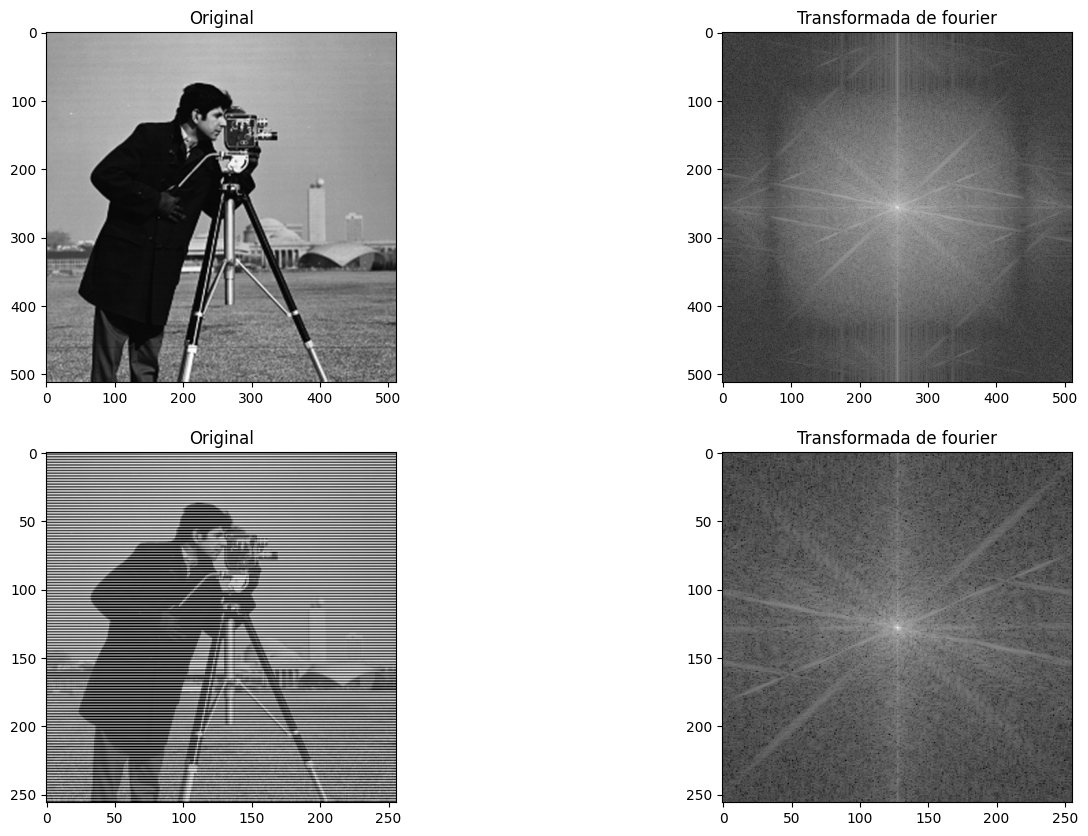

In [25]:
fourier = { 
    name: { 
"tft": apply_fourier_transform(img)[1], 
"spectrum": apply_fourier_transform(img)[0] 
    } 
for name, img in imgs.items() 
} 
# Mostrar imagem resultante 
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 10)) 
for _ax, name in zip(ax, fourier.keys()): 
    _ax[0].imshow(imgs[name], cmap='gray') 
    _ax[0].set_title('Original') 
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray') 
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off') 
#_ax[1].axis('off')
 # fig.savefig("assets/atv02-q09-init.png", bbox_inches='tight', dpi=400) 
plt.show() 

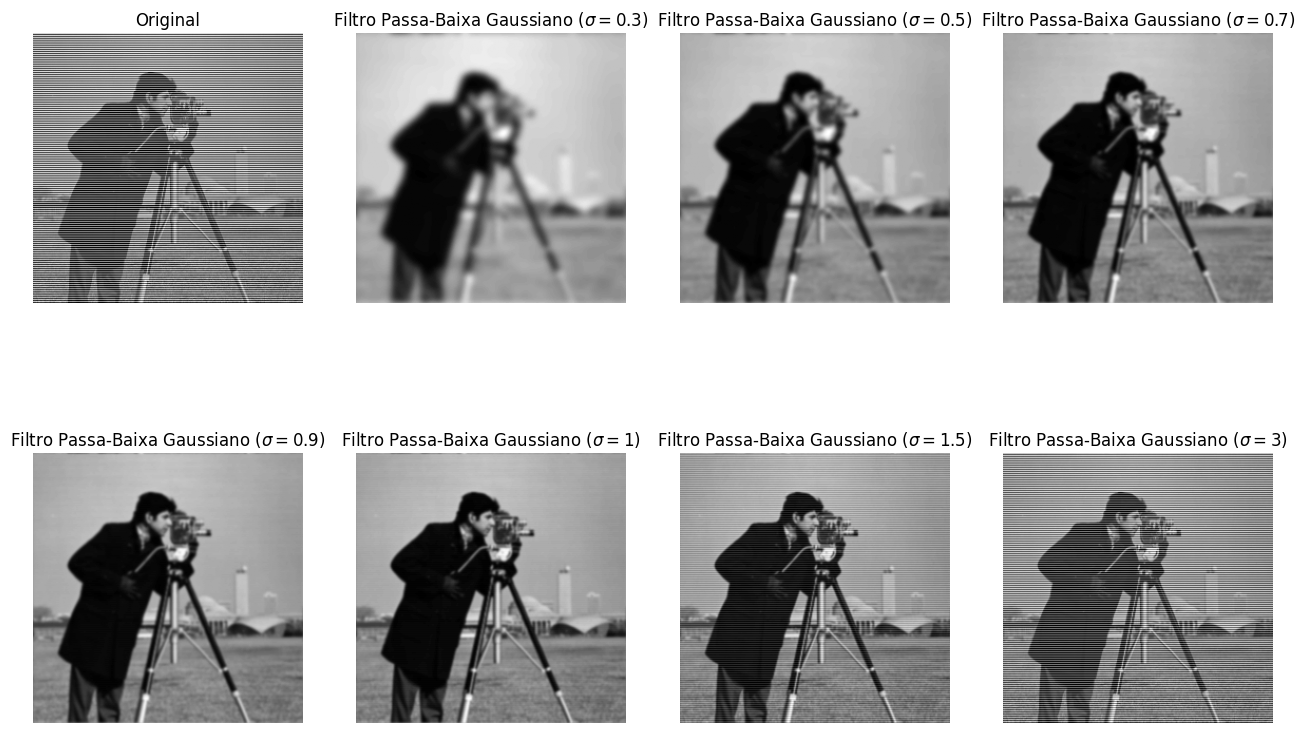

In [27]:
img = imgs["cameraman_pattern"] 
# Adaptação do que foi visto em aula, para python:
 # Ref.: Slide 06 - Filtragem - Pagina 50 

  # Aplicar a Transformada de Fourier 
dft = np.fft.fft2(img) 
dft_shift = np.fft.fftshift(dft) 
# Calculando valores para aplicar no filtro passa baixa 
nx = dft.shape[1] 
ny = dft.shape[0] 
cxrange = np.concatenate( 
    ( 
        np.arange(0, nx // 2 + 1), 
        np.arange(-nx // 2 + 1, 0) 
    ) 
) 
cyrange = np.concatenate( 
    ( 
        np.arange(0, ny // 2 + 1), 
        np.arange(-ny // 2 + 1, 0) 
    ) 
) 
cx, cy = np.meshgrid(cxrange, cyrange) 
fxrange = cxrange * 2 * (np.pi / nx) 
fyrange = cyrange * 2 * (np.pi / ny) 
fx, fy = np.meshgrid(fxrange, fyrange) 
# Lista de sigmas a serem testados 
sigmas = [0.3, 0.5, 0.7, 0.9, 1, 1.5, 3] 
fig, ax = plt.subplots(2, (len(sigmas) // 2) + 1, figsize=(16, 10)) 
ax = ax.flatten() 
ax[0].imshow(img, cmap='gray') 
ax[0].set_title('Original') 
for _ax in ax: 
    _ax.axis('off') 
for idx, sigma in enumerate(sigmas): 
# Filtro passa-baixa gaussiano 
    ms = np.exp(-(fx**2 + fy**2) / (2 * (sigma**2))) 
# Aplicar o filtro 
    smoothF = dft * ms 
    smooth = np.abs(ifft2(smoothF)) 
 # Exibir a imagem suavizada 
    ax[idx + 1].imshow(smooth.round().astype(int), cmap='gray') 
    ax[idx + 1].set_title(
        "Filtro Passa-Baixa Gaussiano " + rf"($\sigma={sigma}$)") 
    ax[idx + 1].axis('off') 
# fig.savefig("assets/atv02-q09-a1.png", bbox_inches='tight', dpi=400) 
plt.show()

## B)

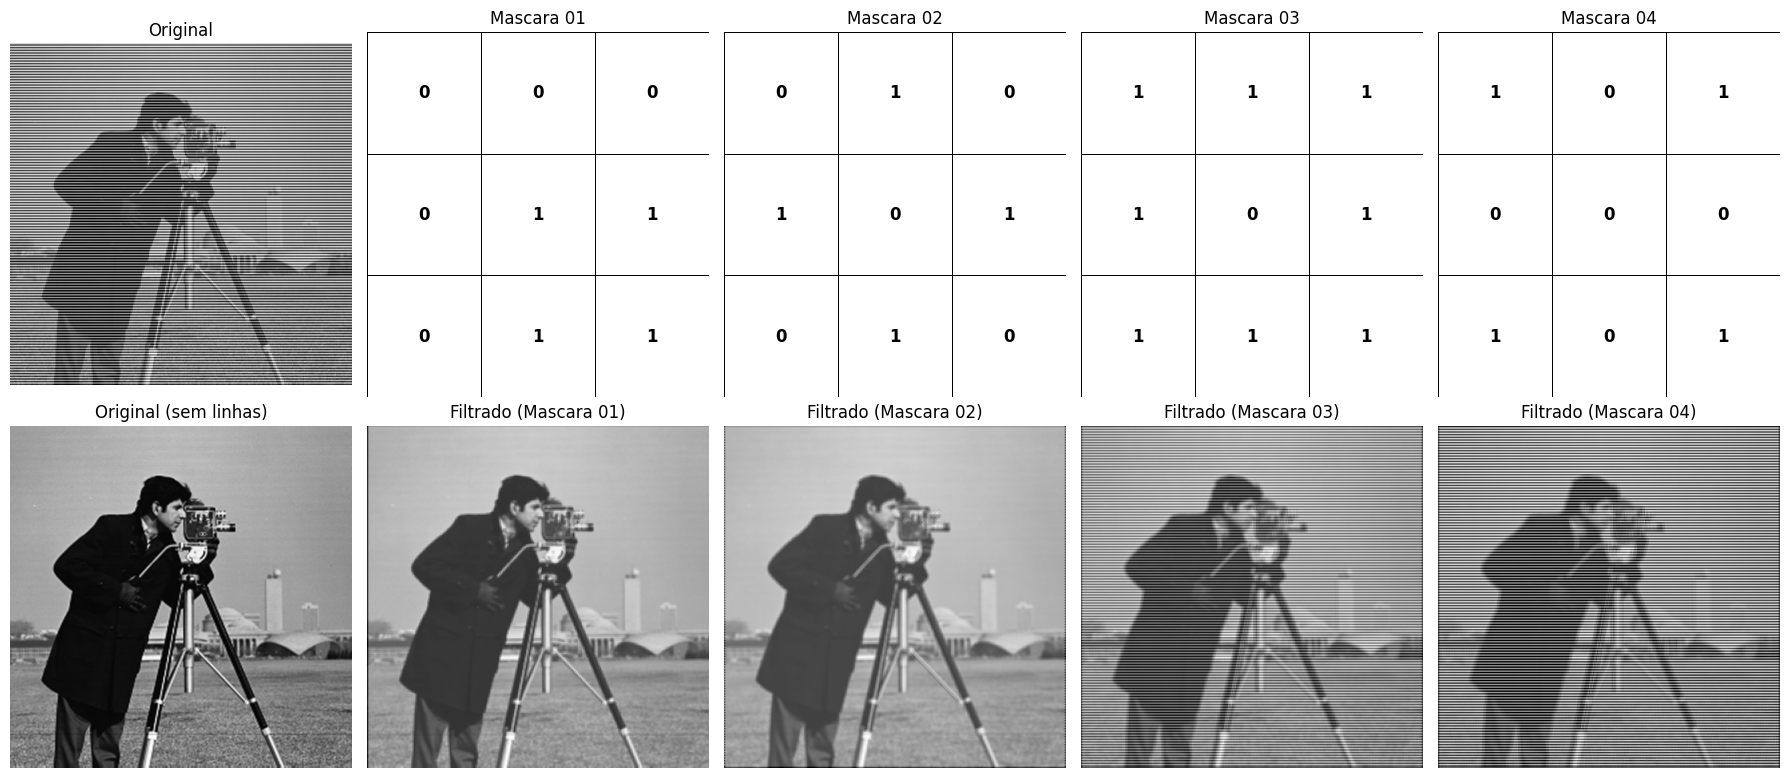

In [33]:
hs = { 
"Mascara 01": np.array( 
        [ 
            [0, 0, 0], 
            [0, 1, 1],
            [0, 1, 1],
        ] 
    ), 
"Mascara 02": np.array( 
        [ 
            [0, 1, 0], 
            [1, 0, 1],
            [0, 1, 0] 
        ]
    ), 
"Mascara 03": np.array( 
        [
            [1, 1, 1],
            [1, 0, 1],
            [1, 1, 1]
        ]
    ), 
"Mascara 04": np.array( 
        [ 
            [1, 0, 1], 
            [0, 0, 0],
            [1, 0, 1]
        ] 
    ), 
} 

for key, h in hs.items(): 
# Normaliza a máscara 
    h = h / np.sum(h) 
# aplicação da correlação cruzada 
filtered_img = { 
    key: convolve2d( 
        imgs["cameraman_pattern"], 
        h, 
        mode='same', 
        boundary='fill', 
        fillvalue=0 
    ).round().astype(int) for key, h in hs.items() 
} 
fig, ax = plt.subplots(2, len(filtered_img.keys()) + 1, figsize=(18, 8)) 

ax[0, 0].set_title('Original') 
ax[0, 0].imshow(imgs["cameraman_pattern"], cmap='gray') 
ax[0, 0].axis('off') 
ax[1, 0].set_title('Original (sem linhas)') 
ax[1, 0].imshow(imgs["cameraman"], cmap='gray') 
ax[1, 0].axis('off') 
# Exibir as máscaras e as imagens filtradas
for _ax, (title, content) in zip(ax.T[1:], filtered_img.items()): 
# Normalizar a máscara para  [0, 1] 
    mask = hs[title] 
    mask_normalized = (mask - mask.min()) / (mask.max() - mask.min()) 
 # _ax[0].imshow(mask_normalized, cmap='gray') 
    sns.heatmap( 
        mask_normalized, 
        ax=_ax[0], 
        cbar=False, 
        annot=True, 
        fmt=".0f", 
        annot_kws={"color": "black", "fontsize": 12, "weight": "bold"},  
        linewidths=0.5, 
        linecolor='black', 
        cmap='binary', 
        vmin=1, vmax=1 
    ) 
    _ax[0].set_title(title) 
    _ax[0].axis('off') 
    _ax[1].imshow(content, cmap='gray') 
    _ax[1].set_title(f"Filtrado ({title})") 
    _ax[1].axis('off') 
fig.tight_layout() 
# fig.savefig("assets/atv02-q09-b2.png", dpi=400, bbox_inches='tight') 
plt.show()

# Questão 10

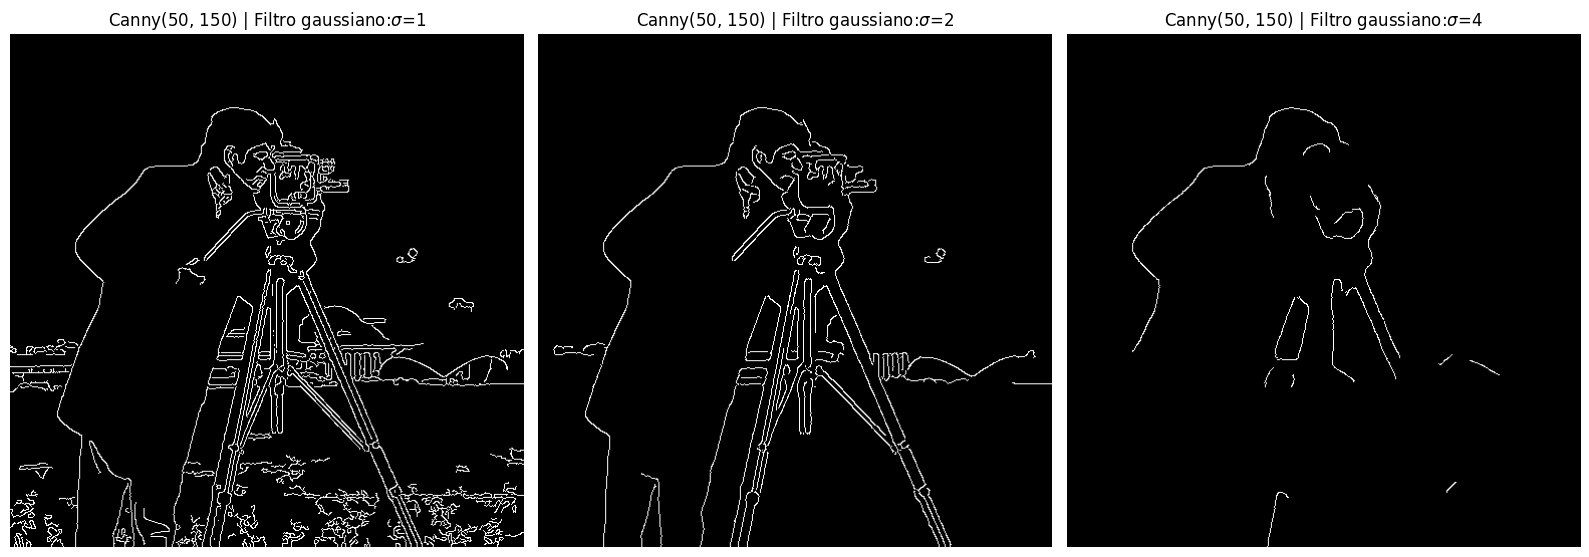

In [35]:
img_names = ["cameraman.png"] 
imgs = { 
    i.split(".")[0]: cv2.imread(f"../assets/atv02_lista02-assets/{i}", cv2.IMREAD_GRAYSCALE) for i in img_names 
}
 # Sigmas para o filtro gaussiano 
sigmas = [1, 2, 4] 
# Parametros para o método de deteccao de canny 
low = 50 
high = 150

fig, ax = plt.subplots(1, len(sigmas), figsize=(16, 8)) 
ax = ax.flatten() 
for i, sigma in enumerate(sigmas): 
# Aplica filtro Gaussiano com sigma definido 
    blurred = cv2.GaussianBlur( 
        imgs["cameraman"], 
        (0, 0), 
        sigmaX=sigma, 
        sigmaY=sigma 
    ) 
# Detecta bordas com Canny 
    edges = cv2.Canny( 
        blurred, 
        low, 
        high 
    ) 
 # Exibe os resultados 
    ax[i].imshow(edges, cmap='gray') 
    ax[i].set_title(
        f'Canny{low, high} | Filtro gaussiano:' + rf'$\sigma$={sigma}'
    ) 
    ax[i].axis('off') 
fig.tight_layout() 
# fig.savefig("assets/atv02-q10-02.png", dpi=400, bbox_inches='tight') 
plt.show()